# Examen Parcial 1 LAE

---
Nombre: **Alan Jesús Hernández Soto** \
Carrera: **Ingeniería Financiera** \
Materia: **Laboratorio de Aprendizaje Estadístico** \
Tipo de Trabajo: **Examen**

---

*Para cada cambio: 1. Que fue el error?, 2. Porque aparecio el error?, 3. Como puedo evitar que pase el error?*

## Carga de Datos

In [648]:
import numpy as np
import pandas as pd

df = pd.read_csv('e01_datos.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       183 non-null    float64
 1   x1      183 non-null    object 
 2   x2      181 non-null    float64
 3   x3      182 non-null    float64
 4   grupo   182 non-null    object 
dtypes: float64(3), object(2)
memory usage: 7.3+ KB


## Limpieza de Datos

**Tipo de Datos**

X1 es una varibale númerica registrada como string, ademas esta en formato de separación por comas y no puntos. Se usa .str ya que si no se usa, Pandas busca en toda la serie (Columna) el valor a buscar y remplazar para así cambiarlo a tipo de dato 'Float'.

In [649]:
df['x1'] = df['x1'].str.replace(',', '.').astype(float)

**Limpiar variables categóricas**

Se limpian las variables para que las observaciones sean uniformes y no afecten la codificación de variables

In [650]:
df['grupo'].unique()

array(['B', 'A', 'a', 'C', ' B ', 'grupo_c', 'AA', 'c', nan, 'b', 'D'],
      dtype=object)

In [651]:
df['grupo'] = df['grupo'].str.rstrip(' ')
df['grupo'] = df['grupo'].replace('a','A')
df['grupo'] = df['grupo'].replace('AA','A')
df['grupo'] = df['grupo'].replace(' B ','B')
df['grupo'] = df['grupo'].replace('grupo_c','C')
df['grupo'] = df['grupo'].replace('c','C')
df['grupo'] = df['grupo'].replace('b','B')
df['grupo'] = df['grupo'].replace(' B','B')

El salón D solo tiene una observación en la regresión por lo tanto se eliminara para que no interfiera en la regresión.

In [652]:
df = df[df['grupo'] != 'D'].reset_index().drop(columns='index')

**Valores nulos y duplicados**

Se imputa los valores nulos con la media y la moda para variables númericas y categóricas respectivamente.

In [653]:
for i in df.columns:
    if df[i].dtype == 'O':
        df[i] = df[i].fillna(df[i].mode()[0])
    else:
        df[i] = df[i].fillna(df[i].median())

df.isnull().sum()

y        0
x1       0
x2       0
x3       0
grupo    0
dtype: int64

No hay valores duplicados

In [654]:
df[df.duplicated()]

,y,x1,x2,x3,grupo


## Ingeniería de Características

Se codifican las variables cualitativas, en este caso grupo, con one-hot, creando una columna binaria por observación única. Así mismo se elmina una columna para tener K-1 dummies y evitar dependencia lineal.

In [655]:
df['A'] = df['grupo'].str.contains('A').astype(int)
df['B'] = df['grupo'].str.contains('B').astype(int)
df['C'] = df['grupo'].str.contains('C').astype(int)
df = df.drop(columns=['grupo', 'C'])

## Regresión

In [656]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
X = df[['x1','x2','x3','A','B']]
Y = df['y']

lr.fit(X,Y)
R2 = lr.score(X,Y)
B0 = lr.intercept_
B1, B2, B3, B4, B5= lr.coef_

print(f'y = {B0:.2f} + {B1:.2f}*x1 + {B2:.2f}*x2 + {B3:.2f}*x3 + {B4:.2f}*A + {B5:.2f}*B')
print(f'R2 = {R2:.4f}')
y_pred = lr.predict(X)
e = Y - y_pred

results = pd.DataFrame({ 'y':Y, 'y_pred':y_pred, 'e':e})

y = 4.29 + 0.61*x1 + 0.26*x2 + 0.66*x3 + 2.21*A + 4.91*B
R2 = 0.5951


$$ \hat{y} = 4.29 + 0.61X_1 + 0.26X_2 + 0.66X_3 + 2.21A + 4.91B $$

## Análisis de Residuos

Gráfica de Residuos VS valores predichos

[]

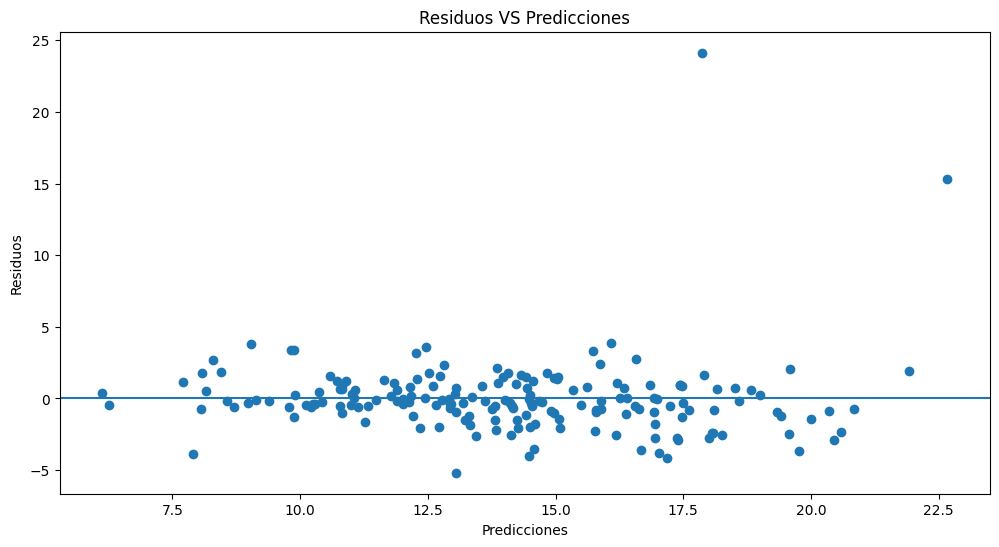

In [657]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))
plt.scatter(y_pred, e)
plt.axhline(0)
plt.title('Residuos VS Predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.plot()

**No Linealidad**

En la gráfica de Residuos VS Prediccioens, toda la información parece capturada ya que a simple vista no se ve ninguna forma curveada.

**Correlación en Errores**

[]

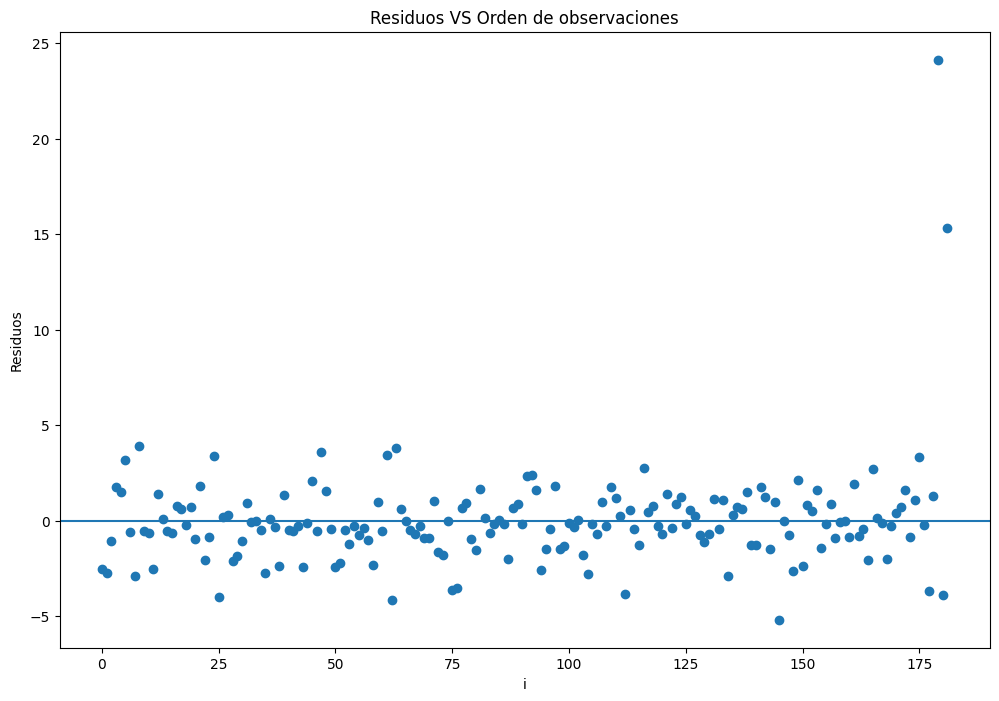

In [658]:
plt.figure(figsize=(12,8))
plt.scatter(results.index.tolist(), results['e'])
plt.axhline(0)
plt.title('Residuos VS Orden de observaciones')
plt.xlabel('i')
plt.ylabel('Residuos')
plt.plot()


No hay patron que de insights de correlación entre los residuos.

**Heterocedasticidad**

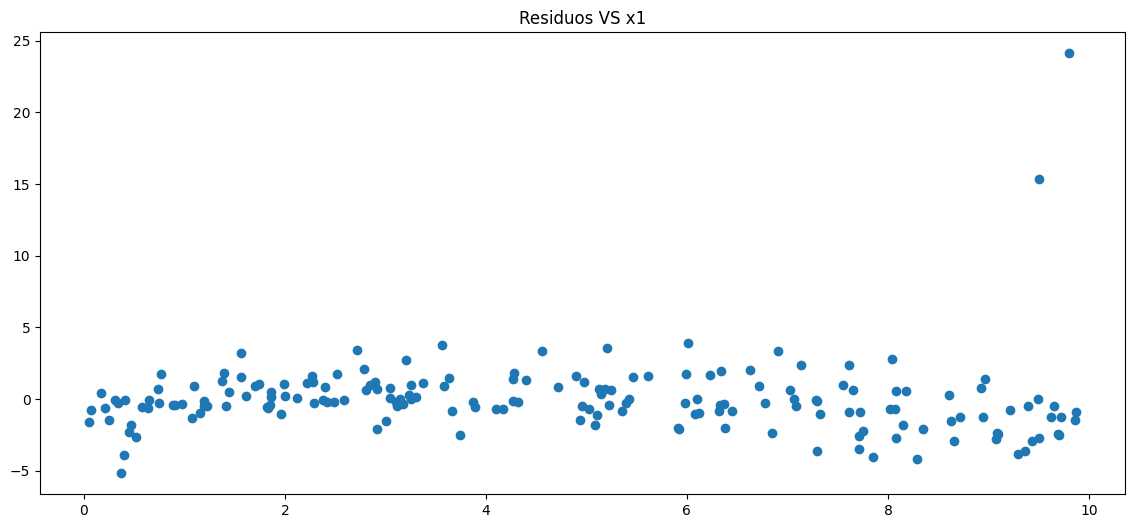

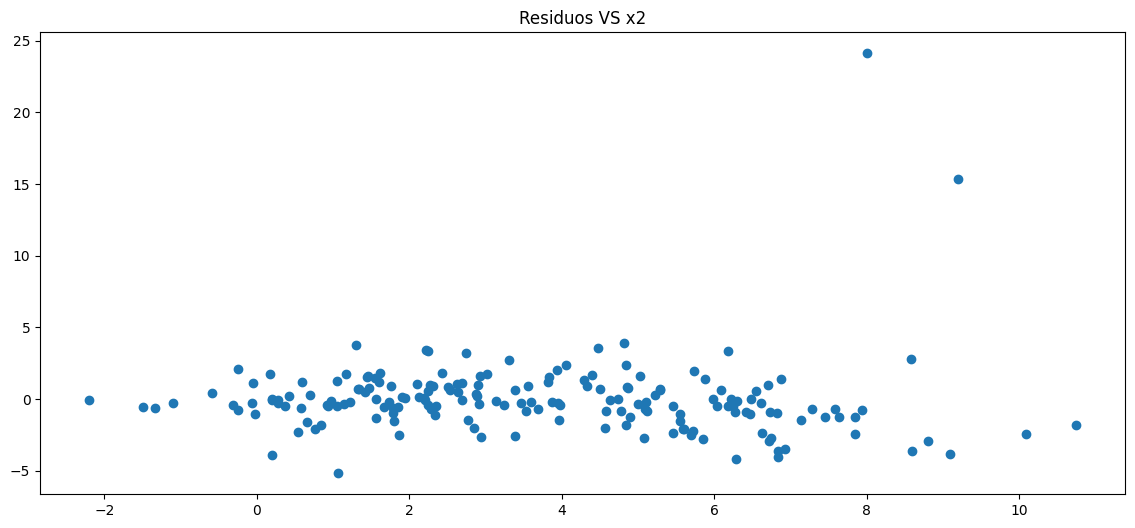

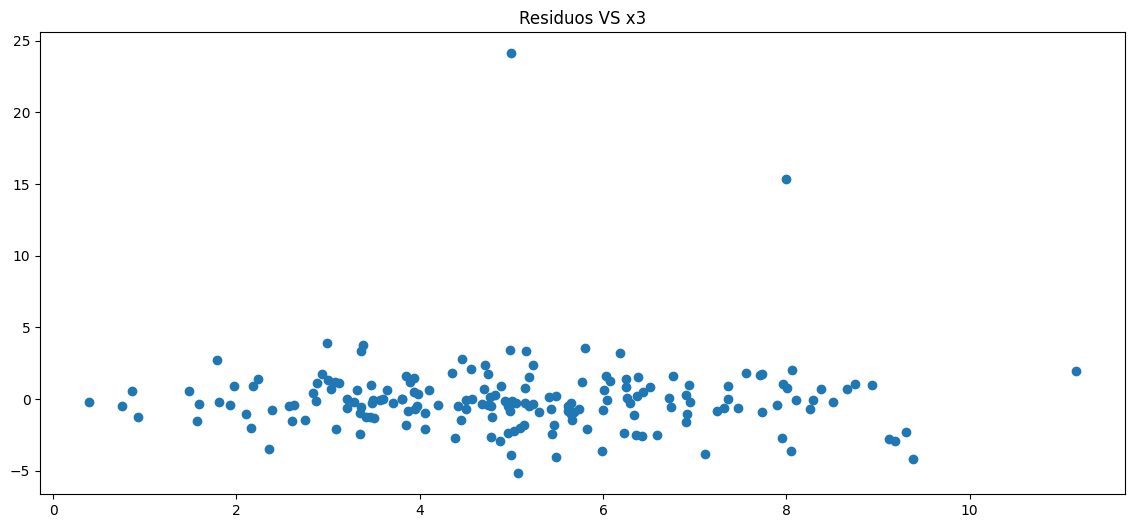

In [659]:
for i in X.columns:
    if df[i].dtype == 'float':
        plt.figure(figsize=(14,6))
        plt.scatter(X[i], e)
        plt.title(f'Residuos VS {i}')
        plt.show()
    else:
        continue

La varianza en todas las gráficas es constante.

**Valores Atípicos**

In [660]:
results['VA'] = abs(results['e']) / results['e'].std()
va = results[results['VA'] > 3].index.tolist()
results = results.drop(va).reset_index()
results = results.drop(columns='index')
X_new = X.drop(va).reset_index()
X_new = X_new.drop(columns='index')
Y_new = Y.drop(va).reset_index()
Y_new = Y_new.drop(columns='index')


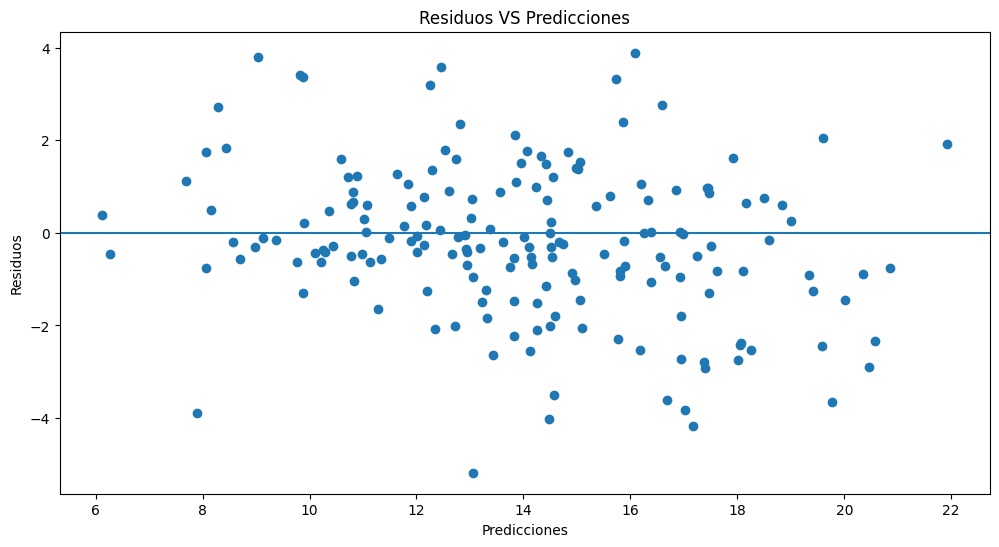

In [661]:
plt.figure(figsize=(12,6))
plt.scatter(results['y_pred'], results['e'])
plt.axhline(0)
plt.title('Residuos VS Predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.show()

**Puntos Palanca en X**

Como es una regresión lineal multiple, la formula de el libro 'An Introduction to Statistical Learning' se invalida ya que es valida para regresiones simples, por lo tanto se calcula la matriz Hat (H) la cual es la matriz que transforma los valores de $y$ en $\hat{y}$ | $\hat{y} = Hy$, para el calculo de esta matriz se uso la formula $ H = X(X^TX)^{-1}X^T $ para esta formula es necesario que X no tenga dependencias lineales, al tener 3 columnas dummies es posible construir el intercepto con esta por lo tanto no tiene inversa, por esto se usa la pseudoinversa la cual es una alternativa que da el mismo resultado de $H$ de tener una X con k-1 dummies. Esta última,  encuentra la solución que ajusta lo mejor posible los datos y, si hay múltiples coeficientes posibles por columnas redundantes, elige la de menor norma.

Para obtener $h_i$ se usa la diagonal de $H$ ya que mide la influencia individual de cada observación individual sobre su valor predicho. Y el threshold usado es $ h_i \geq \frac{2(p)}{n} $ ya que el visto en clase elimina 47 datos y simplemente indica el apalancamiento promedio de todas las observaciones. Se usara p = 6 para el threshold es decir los factores de la regresión lineal sin dependencia lineal, es decir K-1 dummies.

In [662]:
X_hl = np.column_stack((np.ones(len(X_new)), X_new.to_numpy()))
H = X_hl @ np.linalg.inv((X_hl.T @ X_hl)) @ X_hl.T
hi = np.diag(H)

results['hi'] = hi
threshold = 2 * (X_new.shape[1]) / X_new.shape[0]
pp = results[results['hi'] > threshold].index.tolist()

results = results.drop(pp).reset_index()
results = results.drop(columns='index')
X_new = X_new.drop(pp).reset_index()
X_new = X_new.drop(columns='index')
Y_new = Y_new.drop(pp).reset_index()
Y_new = Y_new.drop(columns='index')

print(f'Columnas Eliminadas por alto leverage: {len(pp)}')

Columnas Eliminadas por alto leverage: 10


**Colinealidad**

In [663]:
lr = LinearRegression()
X_vif = X_new.copy()
R2_vif = np.zeros(len(X_vif.columns))
for i in X_vif.columns:
    x = X_vif.drop(columns=i)
    y = X_vif[i]
    lr.fit(x,y)
    R2_vif[X_vif.columns.get_loc(i)] = lr.score(x,y)
R2_vif

VIF = 1/(1-R2_vif)
if any(VIF > 10):
    print("Hay multicolinealidad en las variables", VIF)
else:
    print("No hay multicolinealidad en las variables", VIF)

No hay multicolinealidad en las variables [5.16901208 5.15176218 1.01328374 1.65859698 1.6953356 ]


En este caso no se presenta una presencia de multicolinealidad necesaria de atención más es una buena observación que las varaibles X1 y X2 tienen un VIF muy parecido, por lo tanto de tener definición de las variables es posible que ambas midan lo mismo y/o tengan una correlación casi perfecta. Por el momento, se mantendran todas las variables.

## Mejora y comparación de modelos

Regresión lineal despues de análisis de residuos

In [664]:
X_new = X_new.to_numpy()
Y_new = Y_new.to_numpy()

lr = LinearRegression()
lr.fit(X_new, Y_new)
B0n = lr.intercept_[0]
B1n, B2n, B3n, B4n, B5n = lr.coef_.flatten()
R2n = lr.score(X_new, Y_new)

print(f'y = {B0n:.2f} + {B1n:.2f}*x1 + {B2n:.2f}*x2 + {B3n:.2f}*x3 + {B4n:.2f}*A + {B5n:.2f}*B')
print(f'R2 = {R2n:.4f}')
y_pred_n = lr.predict(X_new)
e_new = Y_new - y_pred_n

y = 5.64 + 0.60*x1 + 0.12*x2 + 0.56*x3 + 1.56*A + 4.37*B
R2 = 0.7536


$$ \hat{y} = 5.64 + 0.60X_1 + 0.12X_2 + 0.56X_3 + 1.56A + 4.37B $$

In [665]:
MSE_new = (np.sum(e_new**2) / len(e_new))
MSE = (np.sum(e**2) / len(e))

comp = pd.DataFrame({'Regresion Original': [B0, B1, B2, B3, B4, B5, R2*100, MSE],
                     'Regresion Corregida': [B0n, B1n, B2n, B3n, B4n, B5n, R2n*100, MSE_new]},
                     index=['B0', 'B1', 'B2', 'B3', 'B4', 'B5', 'R2', 'MSE'])
display(comp)

,Regresion Original,Regresion Corregida
B0,4.293485,5.635366
B1,0.610574,0.601628
B2,0.258938,0.118379
B3,0.660968,0.555365
B4,2.213167,1.560226
B5,4.909007,4.372306
R2,59.507452,75.356897
MSE,7.190796,2.405327


## Validación Cruzada